Database connected successfully!
Available Tables:
                name
0    sqlite_sequence
1  Player_Attributes
2             Player
3              Match
4             League
5            Country
6               Team
7    Team_Attributes
Dataset Sizes:
Match   : (25979, 115)
League  : (11, 3)
Country : (11, 2)
Team    : (299, 5)
MATCH DATA:
   id  country_id  league_id     season  stage                 date  \
0   1           1          1  2008/2009      1  2008-08-17 00:00:00   
1   2           1          1  2008/2009      1  2008-08-16 00:00:00   
2   3           1          1  2008/2009      1  2008-08-16 00:00:00   
3   4           1          1  2008/2009      1  2008-08-17 00:00:00   
4   5           1          1  2008/2009      1  2008-08-16 00:00:00   

   match_api_id  home_team_api_id  away_team_api_id  home_team_goal  ...  \
0        492473              9987              9993               1  ...   
1        492474             10000              9994               0  ...   


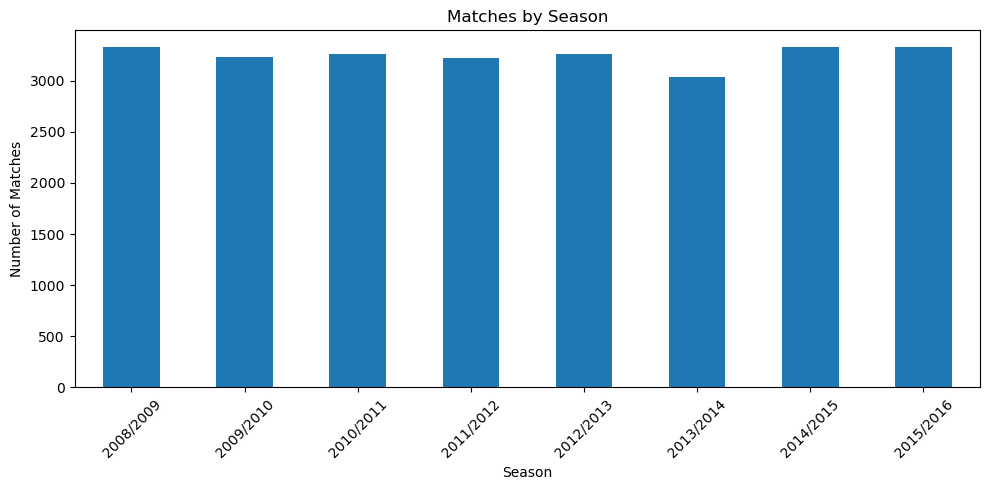

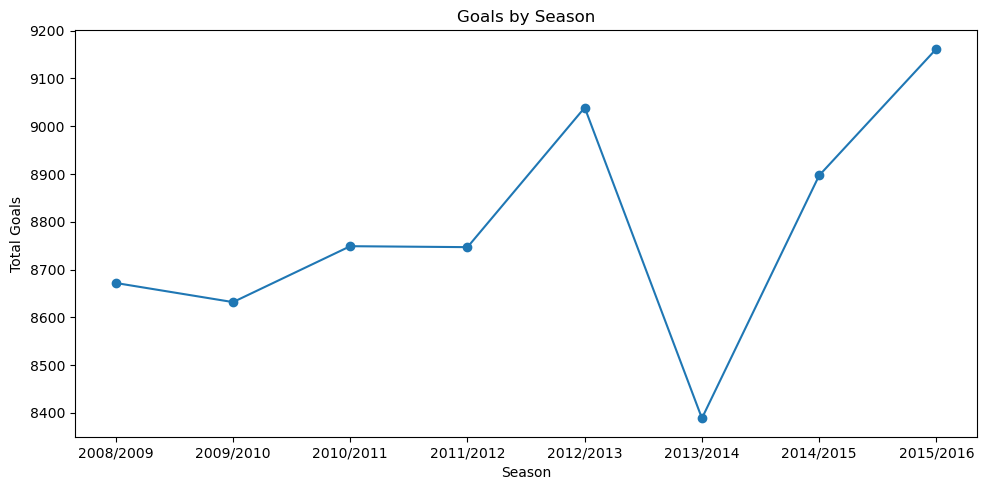

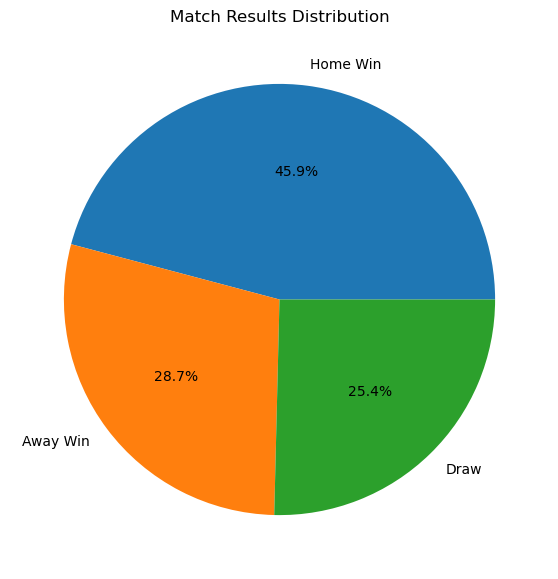

League Information:
       id  country_id                      name
0       1           1    Belgium Jupiler League
1    1729        1729    England Premier League
2    4769        4769            France Ligue 1
3    7809        7809     Germany 1. Bundesliga
4   10257       10257             Italy Serie A
5   13274       13274    Netherlands Eredivisie
6   15722       15722        Poland Ekstraklasa
7   17642       17642  Portugal Liga ZON Sagres
8   19694       19694   Scotland Premier League
9   21518       21518           Spain LIGA BBVA
10  24558       24558  Switzerland Super League
Country Information:
       id         name
0       1      Belgium
1    1729      England
2    4769       France
3    7809      Germany
4   10257        Italy
5   13274  Netherlands
6   15722       Poland
7   17642     Portugal
8   19694     Scotland
9   21518        Spain
10  24558  Switzerland
Team Information:
    team_api_id        team_long_name
0          9987              KRC Genk
1          99

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. CONNECT TO DATABASE
conn = sqlite3.connect("C:/Users/intel/Downloads/database.sqlite/database.sqlite")
print("Database connected successfully!")

# 2. SHOW AVAILABLE TABLES
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

print("Available Tables:")
print(tables)

# 3. LOAD TABLES
match = pd.read_sql("SELECT * FROM Match", conn)
league = pd.read_sql("SELECT * FROM League", conn)
country = pd.read_sql("SELECT * FROM Country", conn)
team = pd.read_sql("SELECT * FROM Team", conn)

print("Dataset Sizes:")
print("Match   :", match.shape)
print("League  :", league.shape)
print("Country :", country.shape)
print("Team    :", team.shape)

# 4. DISPLAY FIRST 5 ROWS
print("MATCH DATA:")
print(match.head())

print("LEAGUE DATA:")
print(league.head())

print("COUNTRY DATA:")
print(country.head())

print("TEAM DATA:")
print(team.head())

# 5. CHECK DATA INFORMATION
print("Match Information:")
match.info()

# 6. CHECK MISSING VALUES
print("Missing Values:")
print(match.isnull().sum())

# 7. STATISTICAL SUMMARY
print("Statistical Summary:")
print(match.describe())

# 8. SELECT IMPORTANT COLUMNS
match_data = match[
    [
        "id",
        "league_id",
        "season",
        "date",
        "home_team_goal",
        "away_team_goal"
    ]
].copy()

# 9. CONVERT DATA TYPES
match_data["home_team_goal"] = pd.to_numeric(
    match_data["home_team_goal"],
    errors="coerce"
)

match_data["away_team_goal"] = pd.to_numeric(
    match_data["away_team_goal"],
    errors="coerce"
)

match_data["season"] = match_data["season"].astype(str)

# 10. HANDLE MISSING VALUES
match_data["home_team_goal"] = match_data["home_team_goal"].fillna(0)
match_data["away_team_goal"] = match_data["away_team_goal"].fillna(0)

# 11. CREATE TOTAL GOALS
match_data["total_goals"] = (
    match_data["home_team_goal"] +
    match_data["away_team_goal"]
)

# 12. CREATE MATCH RESULT
match_data["match_result"] = match_data.apply(
    lambda row:
        "Home Win"
        if row["home_team_goal"] > row["away_team_goal"]
        else "Away Win"
        if row["home_team_goal"] < row["away_team_goal"]
        else "Draw",
    axis=1
)

# 13. DISPLAY CLEANED DATA
print("Cleaned Match Data:")
print(match_data.head(10))

# 14. KPI CALCULATIONS
total_matches = match_data["id"].count()
total_goals = match_data["total_goals"].sum()
average_goals = match_data["total_goals"].mean()
home_wins = (match_data["match_result"] == "Home Win").sum()
away_wins = (match_data["match_result"] == "Away Win").sum()
draws = (match_data["match_result"] == "Draw").sum()

print("SOCCER KPIs")
print("Total Matches :", total_matches)
print("Total Goals   :", total_goals)
print("Average Goals :", round(average_goals, 2))
print("Home Wins     :", home_wins)
print("Away Wins     :", away_wins)
print("Draws         :", draws)

# 15. MATCHES BY SEASON
matches_by_season = match_data.groupby("season")["id"].count()

print("Matches by Season:")
print(matches_by_season)

# 16. GOALS BY SEASON
goals_by_season = match_data.groupby("season")["total_goals"].sum()

print("Goals by Season:")
print(goals_by_season)

# 17. MATCH RESULT COUNT
result_count = match_data["match_result"].value_counts()

print("Match Results:")
print(result_count)

# 18. HIGHEST SCORING MATCHES
highest_scoring = match_data.sort_values(
    "total_goals",
    ascending=False
)

print("Top 10 Highest Scoring Matches:")
print(
    highest_scoring[
        [
            "id",
            "home_team_goal",
            "away_team_goal",
            "total_goals",
            "match_result"
        ]
    ].head(10)
)

# 19. PLOT MATCHES BY SEASON
plt.figure(figsize=(10, 5))
matches_by_season.plot(kind="bar")
plt.title("Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 20. PLOT GOALS BY SEASON
plt.figure(figsize=(10, 5))
goals_by_season.plot(kind="line", marker="o")
plt.title("Goals by Season")
plt.xlabel("Season")
plt.ylabel("Total Goals")
plt.tight_layout()
plt.show()

# 21. PLOT MATCH RESULT DISTRIBUTION
plt.figure(figsize=(7, 7))
result_count.plot(kind="pie", autopct="%1.1f%%")
plt.title("Match Results Distribution")
plt.ylabel("")
plt.show()

# 22. LEAGUE INFORMATION
print("League Information:")
print(league)

# 23. COUNTRY INFORMATION
print("Country Information:")
print(country)

# 24. TEAM INFORMATION
print("Team Information:")
print(
    team[
        [
            "team_api_id",
            "team_long_name"
        ]
    ].head(20)
)

# 25. SAVE CLEANED CSV
match_data.to_csv(
    "Soccer_Cleaned.csv",
    index=False
)

print("Soccer_Cleaned.csv created!")

# 26. SAVE DATA TO EXCEL
with pd.ExcelWriter(
    "Soccer_Data.xlsx",
    engine="openpyxl"
) as writer:
    match_data.to_excel(
        writer,
        sheet_name="Match",
        index=False
    )
    league.to_excel(
        writer,
        sheet_name="League",
        index=False
    )
    country.to_excel(
        writer,
        sheet_name="Country",
        index=False
    )
    team.to_excel(
        writer,
        sheet_name="Team",
        index=False
    )

print("Soccer_Data.xlsx created!")

# 27. CLOSE DATABASE
conn.close()
print("Database connection closed.")
print("SOCCER ANALYSIS COMPLETED!")